# Model Comparison — Baselines vs GraphSAGE

This notebook loads the saved results from the training scripts and compares
three non-graph baselines (Majority-class, Logistic Regression, Random Forest)
against a 2-layer GraphSAGE GNN.

**No training logic lives here** — this is purely visualization and comparison.

## Section 1 — Load saved results

In [1]:
import json
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

ROOT = pathlib.Path("..").resolve()
OUTPUTS = ROOT / "outputs"

with open(OUTPUTS / "baseline_results.json") as f:
    baseline_results = json.load(f)
with open(OUTPUTS / "gnn_results.json") as f:
    gnn_results = json.load(f)

baseline_preds = pd.read_csv(OUTPUTS / "baseline_predictions.csv")
gnn_preds = pd.read_csv(OUTPUTS / "gnn_predictions.csv")
gnn_curves = pd.read_csv(OUTPUTS / "gnn_training_curves.csv")

# Combine all results into one dict for easy iteration
all_results = {**baseline_results, **gnn_results}
MODEL_NAMES = list(all_results.keys())

print(f"Models loaded: {MODEL_NAMES}")
print(f"GNN best epoch: {gnn_results['graphsage']['best_epoch']}, "
      f"best val F1: {gnn_results['graphsage']['best_val_f1']:.4f}")
print(f"Training curve length: {len(gnn_curves)} epochs")

Models loaded: ['majority', 'logistic_regression', 'random_forest', 'graphsage']
GNN best epoch: 35, best val F1: 0.8696
Training curve length: 65 epochs


## Section 2 — Test-set metric comparison table

A side-by-side table of all key metrics on the **test set** across all models.
This is the most important comparison: which model generalises best to unseen nodes?

In [2]:
metric_keys = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for model_name in MODEL_NAMES:
    test_m = all_results[model_name].get("test", {})
    row = {"model": model_name}
    for k in metric_keys:
        row[k] = test_m.get(k, None)
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index("model")
metrics_df = metrics_df.round(4)

# Highlight the best value in each column
def highlight_max(s):
    is_max = s == s.max()
    return ["font-weight: bold; background-color: rgba(40, 167, 69, 0.25)" if v else "" for v in is_max]

styled = metrics_df.style.apply(highlight_max).format("{:.4f}", na_rep="—")
styled

,accuracy,precision,recall,f1,roc_auc
model,,,,,
majority,0.6000,0.6000,1.0000,0.7500,0.5000
logistic_regression,0.8167,0.9032,0.7778,0.8358,0.8646
random_forest,0.7833,0.7949,0.8611,0.8267,0.9005
graphsage,0.8500,0.8649,0.8889,0.8767,0.9028


In [3]:
# Same table but for the validation set
rows_val = []
for model_name in MODEL_NAMES:
    val_m = all_results[model_name].get("val", {})
    row = {"model": model_name}
    for k in metric_keys:
        row[k] = val_m.get(k, None)
    rows_val.append(row)

val_df = pd.DataFrame(rows_val).set_index("model").round(4)
print("Validation set metrics:")
val_df

Validation set metrics:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
majority,0.6000,0.6000,1.0000,0.7500,0.5000
logistic_regression,0.7833,0.8966,0.7222,0.8000,0.8171
random_forest,0.7167,0.7568,0.7778,0.7671,0.8495
graphsage,0.8500,0.9091,0.8333,0.8696,0.9028


## Section 3 — Confusion matrices

A confusion matrix shows the four possible outcomes for each prediction:
- **True Positive (TP):** predicted critical, actually critical
- **True Negative (TN):** predicted non-critical, actually non-critical
- **False Positive (FP):** predicted critical, actually non-critical
- **False Negative (FN):** predicted non-critical, actually critical

We show one heatmap per model, all from the **test set**.

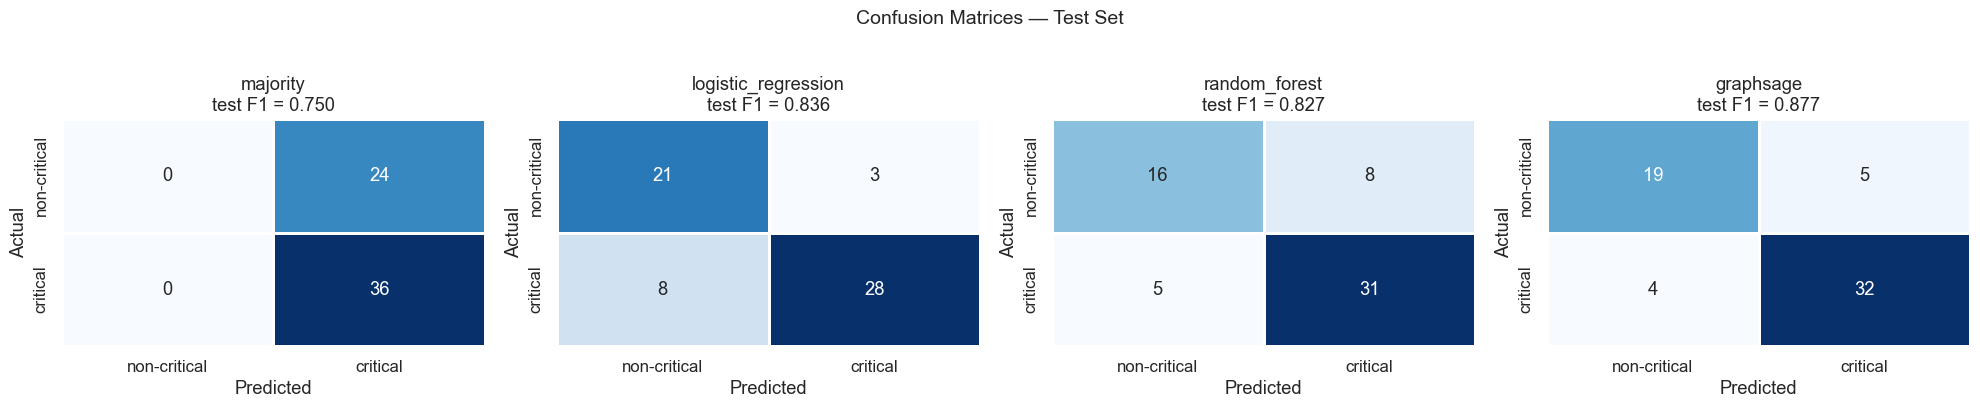

In [4]:
n_models = len(MODEL_NAMES)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

labels_display = ["non-critical", "critical"]

for ax, model_name in zip(axes, MODEL_NAMES):
    cm = all_results[model_name]["test"].get("confusion_matrix")
    if cm is None:
        ax.set_title(f"{model_name}\n(no CM)")
        continue
    cm = np.array(cm)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels_display, yticklabels=labels_display,
                cbar=False, linewidths=1, linecolor="white")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    test_f1 = all_results[model_name]["test"].get("f1", 0)
    ax.set_title(f"{model_name}\ntest F1 = {test_f1:.3f}")

plt.suptitle("Confusion Matrices — Test Set", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Section 4 — GNN training curves

These plots show how the GraphSAGE model learned over training epochs.
- **Train loss** should decrease (the model is fitting the training data).
- **Val loss** should decrease then plateau (if it rises, the model is overfitting).
- **Val F1** shows how well the model generalises at each checkpoint.

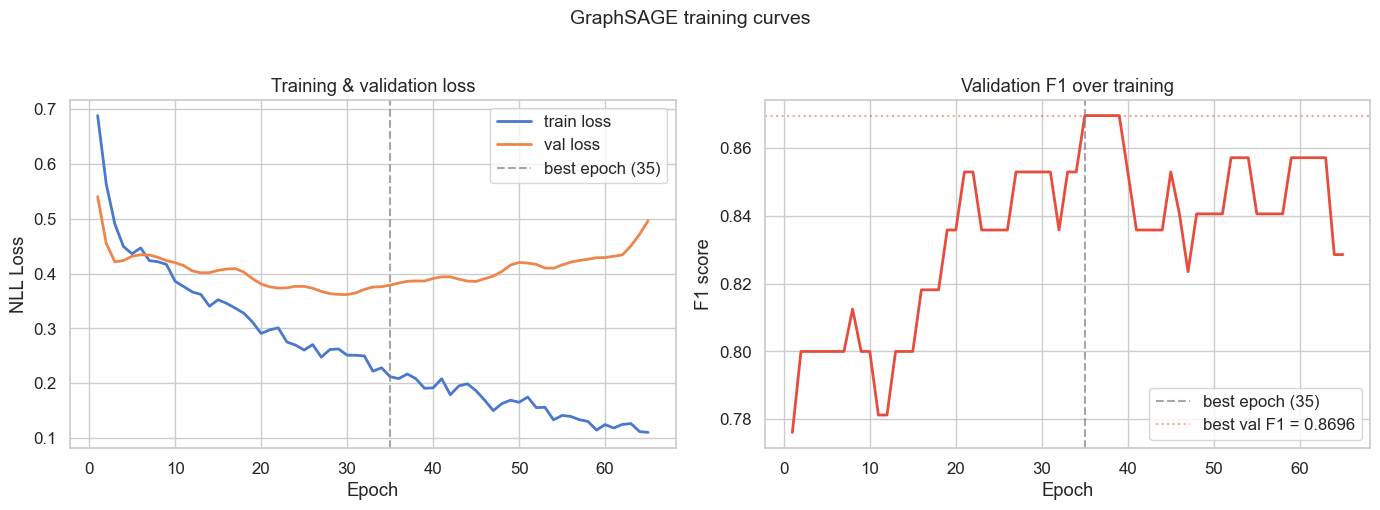

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves ---
axes[0].plot(gnn_curves["epoch"], gnn_curves["train_loss"], label="train loss", linewidth=2)
axes[0].plot(gnn_curves["epoch"], gnn_curves["val_loss"], label="val loss", linewidth=2)
best_ep = gnn_results["graphsage"]["best_epoch"]
axes[0].axvline(best_ep, color="grey", linestyle="--", alpha=0.7, label=f"best epoch ({best_ep})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL Loss")
axes[0].set_title("Training & validation loss")
axes[0].legend()

# --- Val F1 curve ---
axes[1].plot(gnn_curves["epoch"], gnn_curves["val_f1"], color="#e74c3c", linewidth=2)
axes[1].axvline(best_ep, color="grey", linestyle="--", alpha=0.7, label=f"best epoch ({best_ep})")
axes[1].axhline(gnn_results["graphsage"]["best_val_f1"], color="#e74c3c",
                linestyle=":", alpha=0.5, label=f"best val F1 = {gnn_results['graphsage']['best_val_f1']:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 score")
axes[1].set_title("Validation F1 over training")
axes[1].legend()

plt.suptitle("GraphSAGE training curves", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Section 5 — F1 by infrastructure node type

Different node types have very different label distributions (recall from the EDA
that DCs are overwhelmingly critical while PLANTs lean non-critical). This chart
shows how each model handles each type — a model might do well overall but
struggle on a specific type.

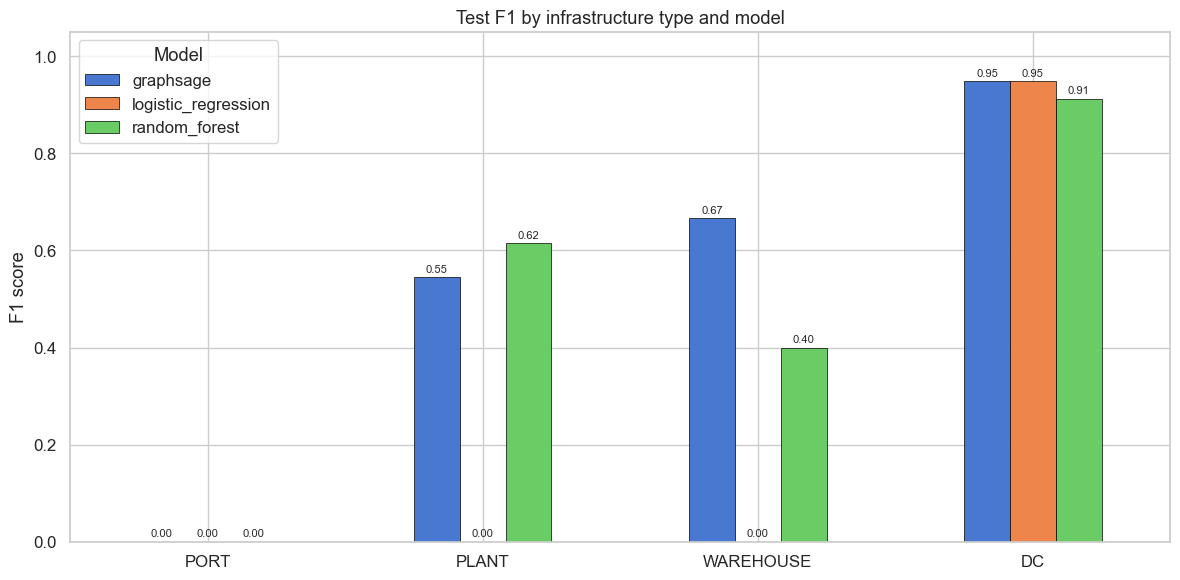


Test F1 by node type:
model      graphsage  logistic_regression  random_forest
node_type                                               
PORT             NaN                  NaN            NaN
PLANT         0.5455               0.0000         0.6154
WAREHOUSE     0.6667               0.0000         0.4000
DC            0.9492               0.9492         0.9123


In [6]:
infra_types = ["PORT", "PLANT", "WAREHOUSE", "DC"]

# Skip majority for the per-type chart (it's a trivial baseline)
chart_models = [m for m in MODEL_NAMES if m != "majority"]

rows_nt = []
for model_name in chart_models:
    by_nt = all_results[model_name].get("test_by_node_type", {})
    for nt in infra_types:
        f1 = by_nt.get(nt, {}).get("f1", None)
        count = by_nt.get(nt, {}).get("count", 0)
        rows_nt.append({"model": model_name, "node_type": nt, "f1": f1, "count": count})

nt_df = pd.DataFrame(rows_nt)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = nt_df.pivot(index="node_type", columns="model", values="f1").reindex(infra_types)
pivot.plot.bar(ax=ax, edgecolor="black", linewidth=0.5)
ax.set_ylabel("F1 score")
ax.set_xlabel("")
ax.set_title("Test F1 by infrastructure type and model")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Model")
ax.set_ylim(0, 1.05)

# Annotate bar values
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# Also print the table
print("\nTest F1 by node type:")
print(pivot.round(4).to_string())

## Section 6 — Metric bar chart comparison

A visual summary of all key metrics side-by-side, making it easy to see
where the GNN outperforms the baselines and where it falls short.

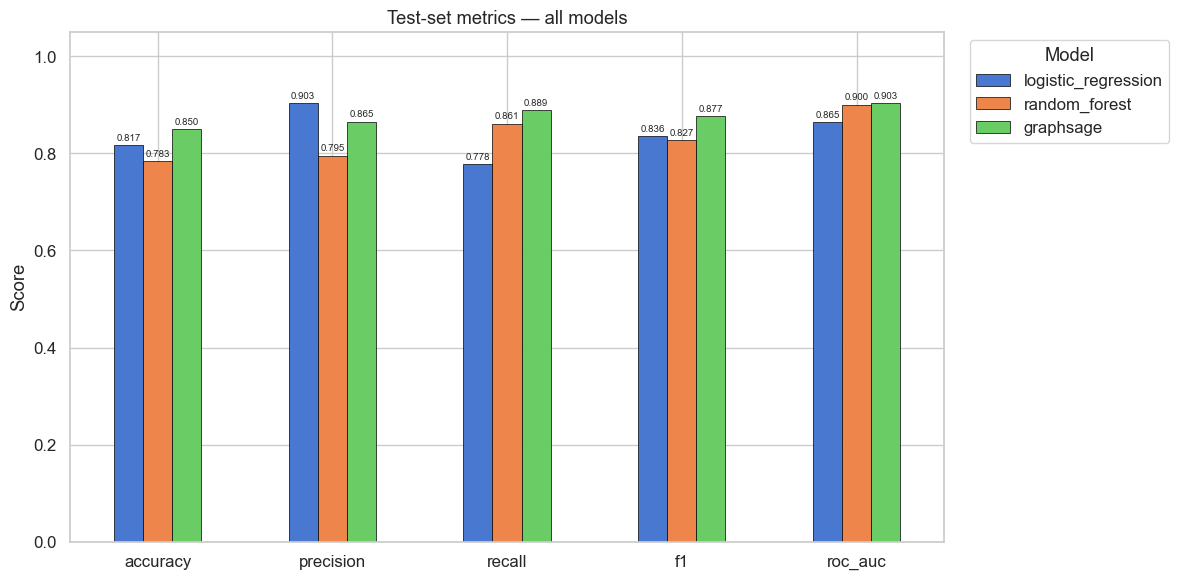

In [7]:
# Skip majority for the bar chart
chart_df = metrics_df.drop("majority", errors="ignore")

fig, ax = plt.subplots(figsize=(12, 6))
chart_df.T.plot.bar(ax=ax, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_title("Test-set metrics — all models")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1.05)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()

## Interpretation

**Majority-class baseline** achieves 60% accuracy simply by always predicting "critical"
(the majority class). It gets perfect recall but zero ability to identify non-critical
nodes. This is the floor — any real model must beat it.

**Logistic Regression and Random Forest** operate on the 26-dimensional node feature
vector without any graph information. They provide a solid feature-only baseline and
show how much signal is available in the raw node attributes alone.

**GraphSAGE** uses the same features but also aggregates information from neighboring
nodes through the graph edges. The comparison between GraphSAGE and the feature-only
baselines reveals whether the graph structure adds predictive value beyond what raw
features already capture.

**Next steps** to potentially improve the GNN:
- Hyperparameter tuning (hidden size, learning rate, number of layers)
- More training data or data augmentation
- Trying other GNN architectures (GCN, GAT)
- Adding edge features to the message passing